<a href="https://colab.research.google.com/github/ozkar0005/Tecmilenio_Tareas/blob/FUNDAMENTOS_Y_APLICACIONES_DE_IA/Fase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

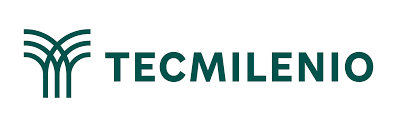

## **UNIVERSIDAD TECMILENIO**

####**MASTER EN INTELIGENCIA ARTIFICIAL**

####**FUNDAMENTOS Y APLICACIONES DE INTELIGENCIA ARTIFICIAL (FASE II)**

* **Nombre del alumno:**  _Oscar Acosta Lira_
* **Nombre de la actividad:**  _FASE II_
* **Nombre del docente:**  _M. en C Luis Ariel Vázquez Piña_
* **Fecha de entrega:**  _07-03-2026_



---

_Declaro que el presente trabajo se realizo con el uso de herramientas de Inteligencia Artificial de tipo generativa (Gemini), para explicación y corrección de errores de sintaxis y la muestra de ejemplos de código al graficar._


---


### **Dataset EDA**
##### **Proyecto: _Predicción del valor del Bitcoin_**
##### **Autor: _Oscar Acosta Lira_**

#### **Titulo: _Precio Bitcoin Factores Dataset_**

#### **Nombre de columnas**
##### Este conjunto de datos contiene información sobre más de 1500 precios de cierre diarios de Bitcoin y de los principales factores que afectan el valor de la criptomoneda.

##### **Características:**
* Fecha - Fecha del precio o valor.
* Bitcoin_Precio_Cierre - Precio de cierre diario del Bitcoin.
* Tasa_de_interes_promedio - Promedio diario de la tasa de interes del Sistema de la Reserva Federal de EE.UU.
* ETF_precio_cierre - Precio de cierre diario del primer ETF de Bitcoin "BITO".
* Halving - Indica si ese dia se realizo un "Halving" de Bitcoin.

#### **Metadata**
##### **Fuente:** Este conjunto de datos se extrajeron de:
* Plataforma finaciera Investing (www.investing.com)
* Sitio oficial de la Federal Reserve Bank of New York (www.newyorkfed.org)
* Plataforma de criptomonedas Ripio (www.ripio.com)

#### **Tarea**

##### Para explorar el conjunto de datos que afectan el precio del Bitcoin y el precio mismo del Bitcoin. Se limpiarán y prepararán los datos para garantizar su precisión y consistencia. Luego, los resumiremos utilizando estadísticas descriptivas como promedios y rangos. Finalmente, visualizaremos los datos con gráficos para identificar patrones, y se realizarán conclusiones.

#### **Objetivos**

##### El objetivo principal de analizar el conjunto de datos del precio del ETF "BITO" y del interes de la Reserva Federal, es  identificar si la variacion de alguno de estos afecta directamente el precio del Bitcoin. Además de identificar si antes o despues de que ocurre un "Halving" el precio del Bitcoin o del ETF cambian considerablemente.

##### Mostrar la información de manera gráfica para que la información sea mas legible y facíl de analizar.

#### **Version de Python usada**
#####Python 3.12.0

#### **Importación de Librerias**

##### Utilizaremos las siguientes librerias:

1. _Pandas:_  Manipulación y análisis de datos
2. _Numpy:_  Operaciones y cálculos numéricos
3. _Matplotlib:_  Visualización y representación gráfica de datos
4. _Seaborn:_ Visualización de datos mejorada y gráficos estadísticos


In [439]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### **Cargar el archivo CSV y crear el dataframe.**

In [440]:
df = pd.read_csv('Valores_Bitcoin_factores.csv')
# se borra la primer columna ya ques es irrelevante
df.drop(df.columns[0], axis=1, inplace=True)
df = pd.DataFrame(df)


##### **Se establece la opción para mostrar el máximo de columnas.**

In [441]:
pd.set_option('display.max_columns', None)

##### **Adelanto de los datos**
##### El propósito de un adelanto es obtener una visión general rápida de los datos e identificar posibles problemas o áreas de interés.

In [442]:
df.head(5)

,Fecha,Bitcoin Precio Cierre,Tasa de interes promedio,ETF precio cierre,Halving
0,06.02.2026,"71,174.10",3.65819,"9,84",NO
1,05.02.2026,"62,857.90",3.65853,"8,80",NO
2,04.02.2026,"73,137.00",3.66020,"10,15",NO
3,03.02.2026,"75,724.80",3.66221,"10,57",NO
4,02.02.2026,"78,720.60",3.66420,"10,79",NO


##### **Nombre de las columnas.**

In [443]:
df.columns

Index(['Fecha', 'Bitcoin Precio Cierre', 'Tasa de interes promedio',
       'ETF precio cierre', 'Halving'],
      dtype='object')

##### **Forma del conjunto de datos.**

In [444]:
print(f"El número de filas es: {df.shape[0]}, el número de columnas es {df.shape[1]}.")

El número de filas es: 1571, el número de columnas es 5.


##### **Información detallada de los datos.**

In [445]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Fecha                     1571 non-null   object 
 1   Bitcoin Precio Cierre     1571 non-null   object 
 2   Tasa de interes promedio  1072 non-null   float64
 3   ETF precio cierre         1079 non-null   object 
 4   Halving                   1571 non-null   object 
dtypes: float64(1), object(4)
memory usage: 61.5+ KB


##### **Suma de valores nulos por columna.**

In [446]:
df.isnull().sum()

,0
Fecha,0
Bitcoin Precio Cierre,0
Tasa de interes promedio,499
ETF precio cierre,492
Halving,0


##### **Observación**
##### El conjunto de datos tiene 1571 filas y 5 columnas.
##### Solo la columna "Tasa de interes promedio" es de tipo float64 y las demás son de tipo object.
##### Las columnas "Tasa de interes promedio" y "ETF precio cierre" tienen algunos datos faltantes.


##### **Cambio de tipo de datos de object a float.**

In [447]:
df['Bitcoin Precio Cierre'] = df['Bitcoin Precio Cierre'].str.replace(',','').astype('float64')
df['ETF precio cierre'] = df['ETF precio cierre'].str.replace(',','.').astype('float64')
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
df['Halving'] = df['Halving'].replace('NO', False)
df['Halving'] = df['Halving'].replace('SI', True)


/tmp/ipykernel_207/821005199.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Halving'] = df['Halving'].replace('SI', True)


##### **Estadísticas descriptivas**

In [448]:
df.describe()

,Fecha,Bitcoin Precio Cierre,Tasa de interes promedio,ETF precio cierre
count,1571,1571.000000,1072.000000,1079.000000
mean,2023-12-13 23:59:59.999999744,56901.198027,3.788365,19.772549
min,2021-10-20 00:00:00,15776.200000,0.047670,8.800000
25%,2022-11-16 12:00:00,27949.950000,3.360370,14.610000
50%,2023-12-14 00:00:00,48599.700000,4.350200,19.170000
75%,2025-01-09 12:00:00,86572.550000,5.305830,23.440000
max,2026-02-06 00:00:00,124725.100000,5.353530,43.320000
std,NaN,31605.571662,1.791288,6.326508


##### **Datos faltantes**
##### Se muestra la cantidad y porcentaje de los datos faltantes.

In [449]:
df.isnull().sum().sort_values(ascending = False)

,0
Tasa de interes promedio,499
ETF precio cierre,492
Fecha,0
Bitcoin Precio Cierre,0
Halving,0


In [450]:
#se saca porcentaje de los datos faltantes
datos_faltantes = df.isnull().sum()/len(df)*100
(df.isnull().sum()/len(df)*100).sort_values(ascending = False)

,0
Tasa de interes promedio,31.763208
ETF precio cierre,31.317632
Fecha,0.000000
Bitcoin Precio Cierre,0.000000
Halving,0.000000


##### **Grafica de datos faltantes en porcentaje.**

Text(0.5, 1.0, 'Porcentaje de datos faltantes por columna')

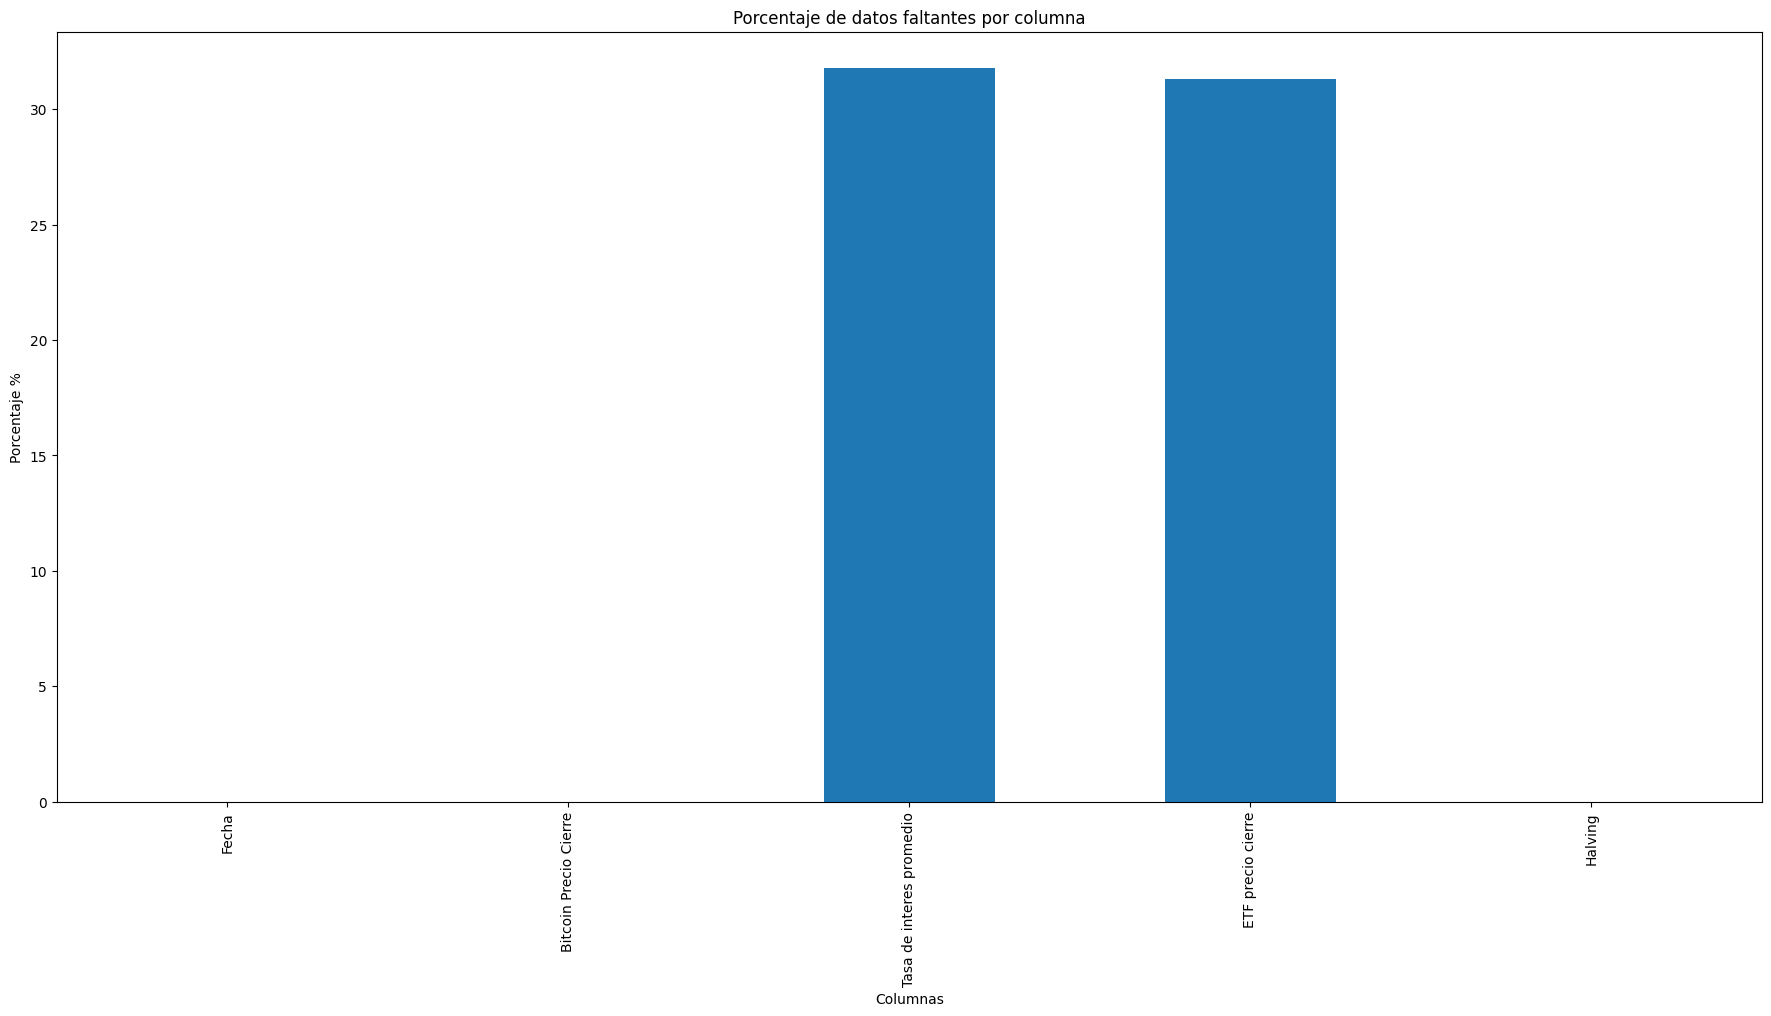

In [451]:
plt.figure(figsize=(22, 10))
datos_faltantes.plot(kind='bar')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje %')
plt.title('Porcentaje de datos faltantes por columna')

##### **Se acompletan valores faltantes con interpolación.**

In [452]:
df['Tasa de interes promedio'] = df['Tasa de interes promedio'].interpolate(method='linear')
df['ETF precio cierre'] = df['ETF precio cierre'].interpolate(method='linear')

##### **Grafico de valores por columna.**

In [453]:
#Se convierten columnas en Arrays
bitcoin_array = df['Bitcoin Precio Cierre'].to_numpy()
interes_array = df['Tasa de interes promedio'].to_numpy()
etf_array = df['ETF precio cierre'].to_numpy()
halving_array = df['Halving'].to_numpy()

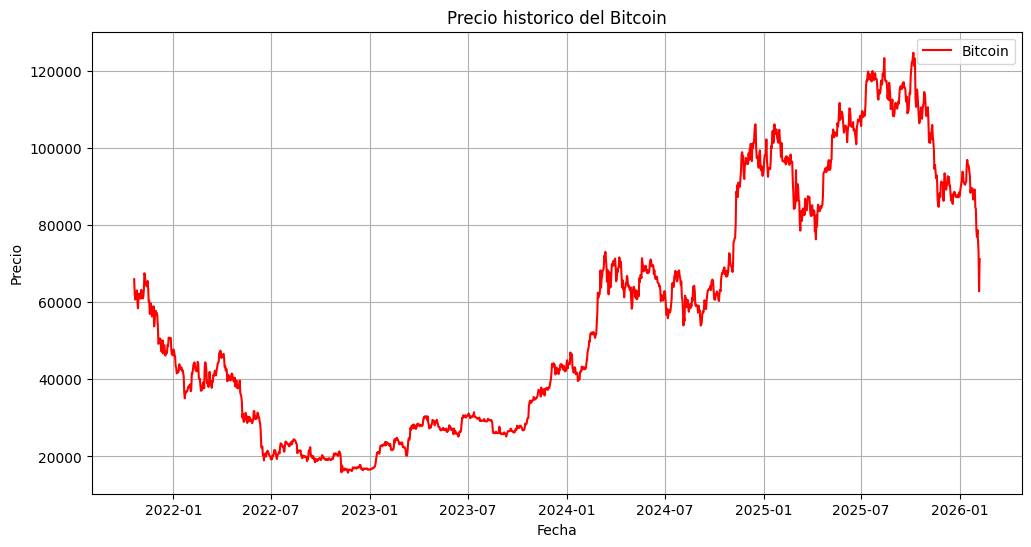

In [454]:
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], bitcoin_array, label='Bitcoin', color='red', linestyle='-')
plt.title('Precio historico del Bitcoin')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

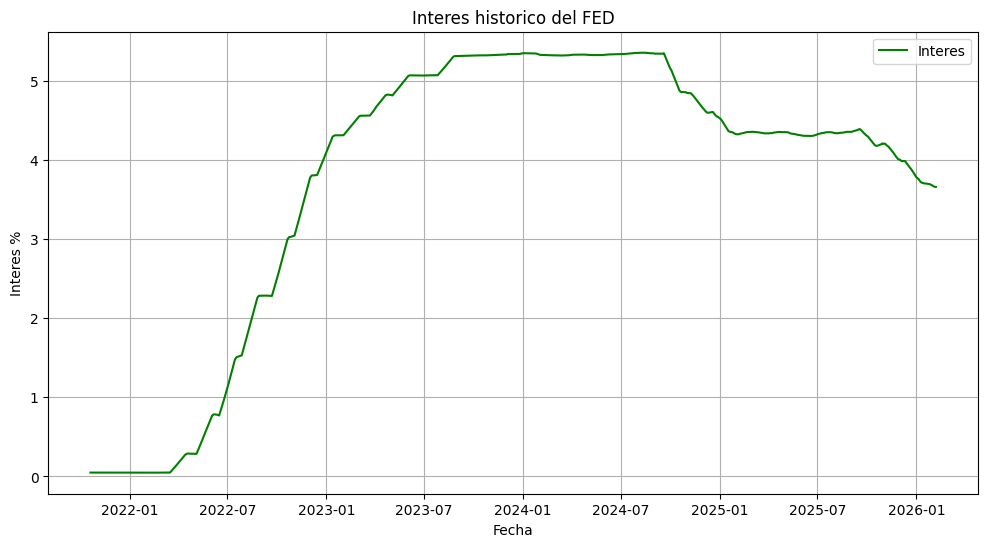

In [455]:
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], interes_array, label='Interes', color='green', linestyle='-')
plt.title('Interes historico del FED')
plt.xlabel('Fecha')
plt.ylabel('Interes %')
plt.legend()
plt.grid(True)
plt.show()

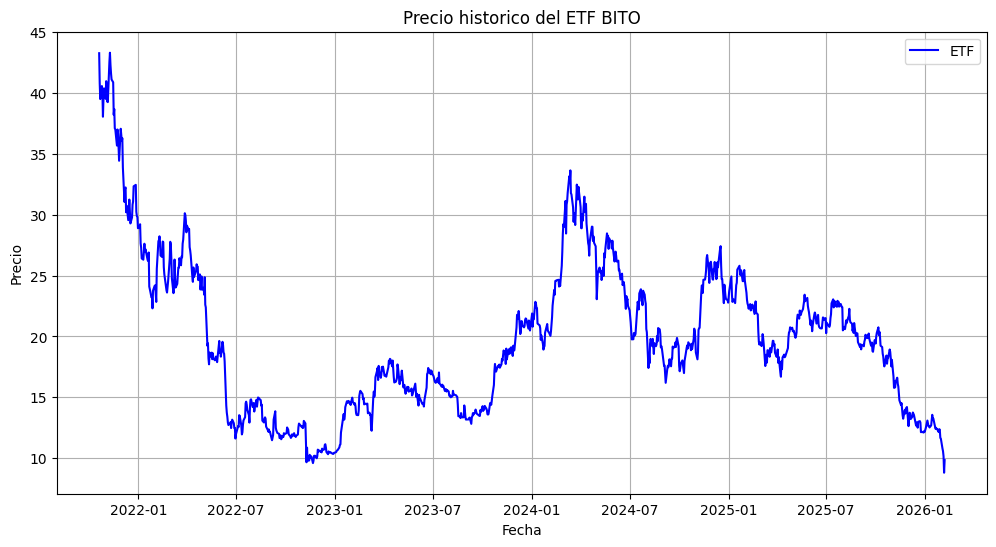

In [456]:
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], etf_array,label='ETF', color='blue', linestyle='-')
plt.title('Precio historico del ETF BITO')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

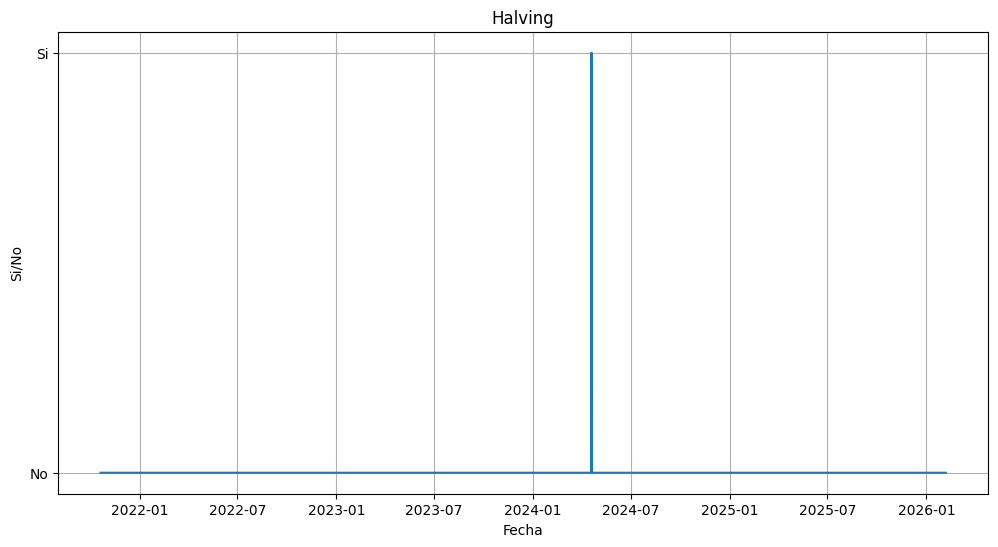

In [457]:
plt.figure(figsize=(12, 6))
plt.plot(df['Fecha'], halving_array)
plt.yticks([0, 1], ['No', 'Si'])
plt.title('Halving')
plt.xlabel('Fecha')
plt.ylabel('Si/No')
plt.grid(True)
plt.show()

##### **Grafica multiple con todos los valores**

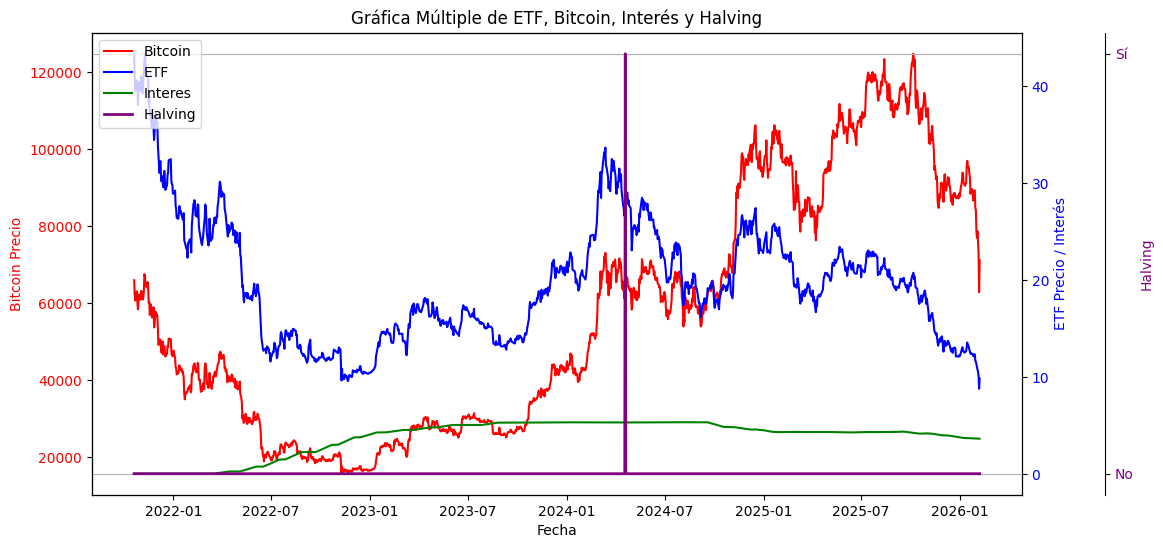

In [458]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Grafica de Bitcoin
ax1.plot(df['Fecha'], bitcoin_array, label='Bitcoin', color='red', linestyle='-')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Bitcoin Precio', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Grafica de interes y ETF
ax2 = ax1.twinx()
ax2.plot(df['Fecha'], etf_array, label='ETF', color='blue', linestyle='-')
ax2.plot(df['Fecha'], interes_array, label='Interes', color='green', linestyle='-')
ax2.set_ylabel('ETF Precio / Interés', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Grafica de Halving
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df['Fecha'], halving_array, label='Halving', color='purple', linestyle='-', linewidth=2)
ax3.set_ylabel('Halving', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['No', 'Sí'])

plt.title('Gráfica Múltiple de ETF, Bitcoin, Interés y Halving')

# Combina etiquetas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.grid(True)
plt.show()

##### **Concluciones**
##### En la grafica anterior se puede observar:
1. El precio del Bitcoin esta estrechamente ligado al precio del ETF BITO. Lo que significa que cuando los inversionistas grandes de Bitcoin (denominados "ballenas") venden o compran ETF de Bitcoin. El precio de la criptomoneda se ve afectada debido a que psicologicamente genera confianza o desconfianza en la mayoria de los inversionistas. Afectando la oferta y demanda y por consecuencia el precio de la criptomoneda.

2. Cuando la tasa de interes de la Reserva Federal de EE.UU. (FED) sube, el precio del Bitcoin cae y viseversa. Esto debido a que cuando la tasa de interes baja, a los inversionistas no les interesa prestar dinero y buscan invertir en otros recursos como son las criptomonedas. Lo que sube la demanda y por consecuencia el precio.

3. Cuando se aproxima un "Halving", el precio del Bitcoin se dispara. Y despues del "Halving", el precio disminuye. Esto debiudo al efecto psicologico de que el Bitcoin se vuelva mas escaso y con mayor demanda.